In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os.path
from scipy.spatial.distance import cdist
import time
from tqdm import tqdm
import pandas as pd

In [3]:
#scope_lol_ns = pd.read_csv("100vsall/classifier_sorted_newscore.rocx", delimiter= "\t")
scope_lol_ns_len = pd.read_csv("allvsall_lol.rocx", delimiter= "\t")
scope_lol_ns_len_pref = pd.read_csv("allvsall_pref.rocx", delimiter= "\t")
scope_tm = pd.read_csv("allvsall_tmsort.rocx", delimiter= "\t")
scope_dali = pd.read_csv("dali_sorted.rocx", delimiter= "\t")
scope_fs = pd.read_csv("allvsall_fs.rocx", delimiter= "\t")
scope_tmpref = pd.read_csv("allvsall_tmpref.rocx", delimiter= "\t")

In [ ]:
runtime_indices = [3, 4, 0, 1, 2, 5]

In [32]:
123010/16986

7.241846226304015

In [35]:
# Define scale and runtime data
scale = np.arange(0,3566)/3565
runtime = [123010, 62240, 42, 18120, 1320, 1480]

c = ["FAM", "SFAM", "FOLD"]

# Strong, vibrant color palette
colors = {
    "Dali": "#FFA500",           
    "TM-align": "#138BD1",       
    "Foldseek": "#00AA00",       
    "LoLalign": "#FF0000",       
    "Foldseek-LoL": "#FF1493",   
    "Foldseek-Tm": "#9932CC"     
}
marker = {"Dali": 'o',           
    "TM-align": '^',       
    "Foldseek": 'd',       
    "LoLalign": "*",       
    "Foldseek-LoL": 's',   
    "Foldseek-Tm": 'v'
    }



# Publication-quality figure settings
plt.rcParams.update({
    'figure.figsize': (8, 6),
    'font.size': 12,
    'axes.labelsize': 20,
    'axes.titlesize': 16,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 14,
    'lines.linewidth': 2.5,
    'grid.alpha': 0.3,
    'figure.dpi': 100
})

In [36]:
runtime = [123010, 62240, 42, 18120, 1320, 1480]
c = ["FAM", "SFAM", "FOLD"]

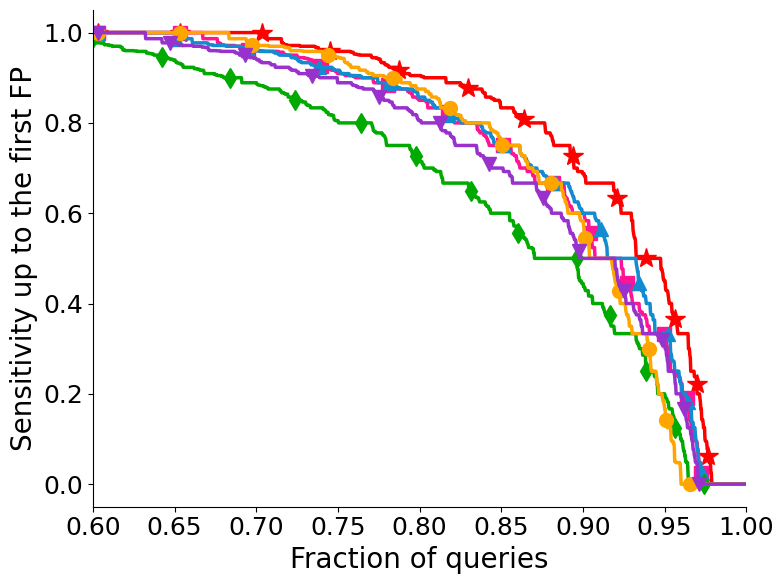

In [37]:
plt.plot(scale, np.sort(scope_lol_ns_len["FAM"].values)[::-1],
         label='LoLalign', color=colors["LoLalign"], linewidth=2.5,
         marker='*', markersize=15, markevery=0.1)

plt.plot(scale, np.sort(scope_lol_ns_len_pref["FAM"].values)[::-1],
         label='Foldseek-LoL', color=colors["Foldseek-LoL"], linewidth=2.5,
         marker='s', markersize=10, markevery=0.1)

plt.plot(scale, np.sort(scope_tm["FAM"].values)[::-1],
         label='TM-align', color=colors["TM-align"], linewidth=2.5,
         marker='^', markersize=10, markevery=0.1)

plt.plot(scale, np.sort(scope_fs["FAM"].values)[::-1],
         label='Foldseek', color=colors["Foldseek"], linewidth=2.5,
         marker='d', markersize=10, markevery=0.1)

plt.plot(scale, np.sort(scope_dali["FAM"].values)[::-1],
         label='Dali', color=colors["Dali"], linewidth=2.5,
         marker='o', markersize=10, markevery=0.1)

plt.plot(scale, np.sort(scope_tmpref["FAM"].values)[::-1],
         label='Foldseek-TM', color=colors["Foldseek-Tm"], linewidth=2.5,
         marker='v', markersize=10, markevery=0.1)

plt.xlim([0.2, 1])
plt.xlabel('Fraction of queries', fontsize=20)
plt.ylabel("Sensitivity up to the first FP", fontsize=20)
#plt.legend(frameon=True, fancybox=True, shadow=True,
 #          loc='lower left', fontsize=18)

# Improve axis limits and ticks
plt.xlim(0.6, 1)

plt.tick_params(labelsize=18)


# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('roc1_fam.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.savefig('roc1_fam.png', dpi=300, bbox_inches='tight', format='png')
plt.show()

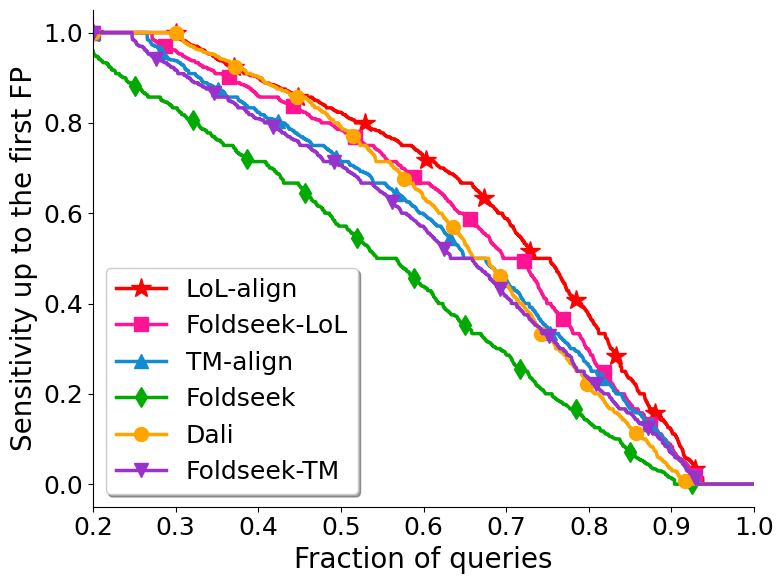

In [38]:
plt.plot(scale, np.sort(scope_lol_ns_len["SFAM"].values)[::-1],
         label='LoL-align', color=colors["LoLalign"], linewidth=2.5,
         marker='*', markersize=15,markevery=0.1)

plt.plot(scale, np.sort(scope_lol_ns_len_pref["SFAM"].values)[::-1],
         label='Foldseek-LoL', color=colors["Foldseek-LoL"], linewidth=2.5,
         marker='s', markersize=10, markevery=0.1)
#plt.plot(0, 0,
#         label='Foldseek-LoL', color=colors["Foldseek-LoL"], linewidth=2.5,
#         marker='s', markersize=10, markevery=0.1)

plt.plot(scale, np.sort(scope_tm["SFAM"].values)[::-1],
         label='TM-align', color=colors["TM-align"], linewidth=2.5,
         marker='^', markersize=10, markevery=0.1)

plt.plot(scale, np.sort(scope_fs["SFAM"].values)[::-1],
         label='Foldseek', color=colors["Foldseek"], linewidth=2.5,
         marker='d', markersize=10, markevery=0.1)

plt.plot(scale, np.sort(scope_dali["SFAM"].values)[::-1],
         label='Dali', color=colors["Dali"], linewidth=2.5,
         marker='o', markersize=10, markevery=0.1)

#plt.plot(0, 0,
#         label='Foldseek-TM', color=colors["Foldseek-Tm"], linewidth=2.5,
#         marker='v', markersize=10, markevery=0.1)
plt.plot(scale, np.sort(scope_tmpref["SFAM"].values)[::-1],
         label='Foldseek-TM', color=colors["Foldseek-Tm"], linewidth=2.5,
         marker='v', markersize=10, markevery=0.1)

plt.xlim([0.2, 1])
plt.xlabel('Fraction of queries', fontsize=20)
plt.ylabel("Sensitivity up to the first FP", fontsize=20)
plt.legend(frameon=True, fancybox=True, shadow=True,
           loc='lower left', fontsize=18)

# Improve axis limits and ticks
plt.xlim(0.2, 1)

plt.tick_params(labelsize=18)

# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#(ax.text(-0.1, 1.05, 'a', transform=ax.transAxes, fontsize=24, fontweight='bold', va='top', ha='right'))


plt.tight_layout()
plt.savefig('roc1_sfam.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.savefig('roc1_sfam.png', dpi=300, bbox_inches='tight', format='png')
plt.show()


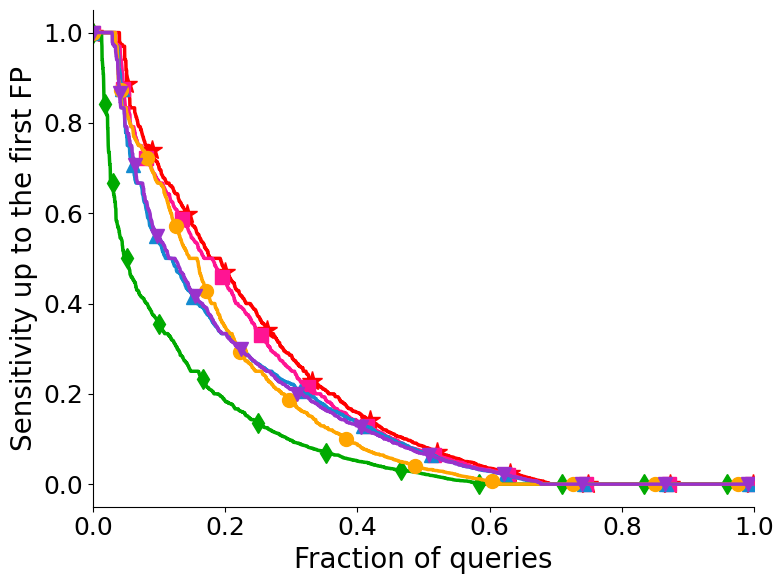

In [44]:
plt.plot(scale, np.sort(scope_lol_ns_len["FOLD"].values)[::-1],
         label='LoLalign', color=colors["LoLalign"], linewidth=2.5,
         marker='*', markersize=15, markevery=0.1)

plt.plot(scale, np.sort(scope_lol_ns_len_pref["FOLD"].values)[::-1],
         label='Foldseek-LoL', color=colors["Foldseek-LoL"], linewidth=2.5,
         marker='s', markersize=10, markevery=0.1)

plt.plot(scale, np.sort(scope_tm["FOLD"].values)[::-1],
         label='TM-align', color=colors["TM-align"], linewidth=2.5,
         marker='^', markersize=10, markevery=0.1)

plt.plot(scale, np.sort(scope_fs["FOLD"].values)[::-1],
         label='Foldseek', color=colors["Foldseek"], linewidth=2.5,
         marker='d', markersize=10, markevery=0.1)

plt.plot(scale, np.sort(scope_dali["FOLD"].values)[::-1],
         label='Dali', color=colors["Dali"], linewidth=2.5,
         marker='o', markersize=10, markevery=0.1)

plt.plot(scale, np.sort(scope_tmpref["FOLD"].values)[::-1],
         label='Foldseek-TM', color=colors["Foldseek-Tm"], linewidth=2.5,
         marker='v', markersize=10, markevery=0.1)

plt.xlim([0.2, 1])
plt.xlabel('Fraction of queries', fontsize=20)
plt.ylabel("Sensitivity up to the first FP", fontsize=20)
#plt.legend(frameon=True, fancybox=True, shadow=True,
#           loc='lower left', fontsize=18)

# Improve axis limits and ticks
plt.xlim(0, 1)

plt.tick_params(labelsize=18)

# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('roc1_fold.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.savefig('roc1_fold.png', dpi=300, bbox_inches='tight', format='png')
plt.show()

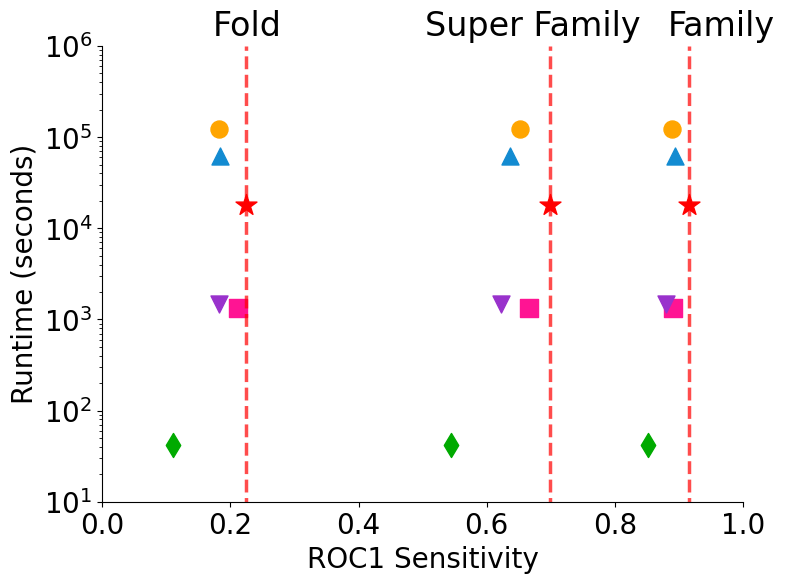

In [ ]:

# Create scatter plot with improved styling
methods = ["LoL-align", "Foldseek-LoL", "Dali", "TM-align Fast", "Foldseek", "Foldseek-TM"]
method_keys = ["LoLalign", "Foldseek-LoL", "Dali", "TM-align", "Foldseek", "Foldseek-Tm"]
data_sources = [scope_lol_ns_len, scope_lol_ns_len_pref, scope_dali, scope_tm, scope_fs, scope_tmpref]
runtime_indices = [3, 4, 0, 1, 2, 5]
markers = ['*', 's', 'o', '^', 'd', 'v']

# Calculate average ROC1 sensitivity for each category
categories = ["FAM", "SFAM", "FOLD"]
category_labels = ["Family", "Superfamily", "Fold"]

for cat_idx, (cat, cat_label) in enumerate(zip(categories, category_labels)):
    sensitivities = []
    for data in data_sources:
        sens = data[cat].values.mean()
        sensitivities.append(sens)
    
    # Plot each method for this category
    for i, (method, key, sens, runtime_idx, marker) in enumerate(zip(methods, method_keys, sensitivities, runtime_indices, markers)):
        if marker == '*':
            plt.scatter(sens, runtime[runtime_idx], 
                  label=f"{method} ({cat_label})" if cat_idx == 0 else "", 
                  color=colors[key], marker=marker, s=250)
            plt.vlines(sens, 0, 10**6, color=colors[key], linewidth=2.5, alpha=0.7, linestyles='dashed')

        else:
            plt.scatter(sens, runtime[runtime_idx], 
                  label=f"{method} ({cat_label})" if cat_idx == 0 else "", 
                  color=colors[key], marker=marker, s=150)

plt.yscale('log')
plt.ylim([10, 10**6])
plt.xlim([0, 1])
plt.ylabel("Runtime (seconds)", fontsize=20)
plt.xlabel("ROC1 Sensitivity", fontsize=20)
plt.tick_params(labelsize=20)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


(ax.text(0.28, 1.08, 'Fold', transform=ax.transAxes, fontsize=24, va='top', ha='right'))
(ax.text(0.84, 1.08, 'Super Family', transform=ax.transAxes, fontsize=24, va='top', ha='right'))
(ax.text(1.05, 1.08, 'Family', transform=ax.transAxes, fontsize=24, va='top', ha='right'))

plt.tight_layout()
plt.savefig('roc1_speed.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.savefig('roc1_speed.png', dpi=300, bbox_inches='tight', format='png')
plt.show()

In [56]:
scope_lol_ns_len = pd.read_csv("allvsall_lol_t5.rocx", delimiter= "\t")
scope_lol_ns_len_pref = pd.read_csv("allvsall_pref_t5.rocx", delimiter= "\t")
scope_tm = pd.read_csv("allvsall_tmsort_t5.rocx", delimiter= "\t")
scope_dali = pd.read_csv("dali_sorted_t5.rocx", delimiter= "\t")
scope_fs = pd.read_csv("allvsall_fs_t5.rocx", delimiter= "\t")
scope_tmpref = pd.read_csv("allvsall_tmpref_t5.rocx", delimiter= "\t")

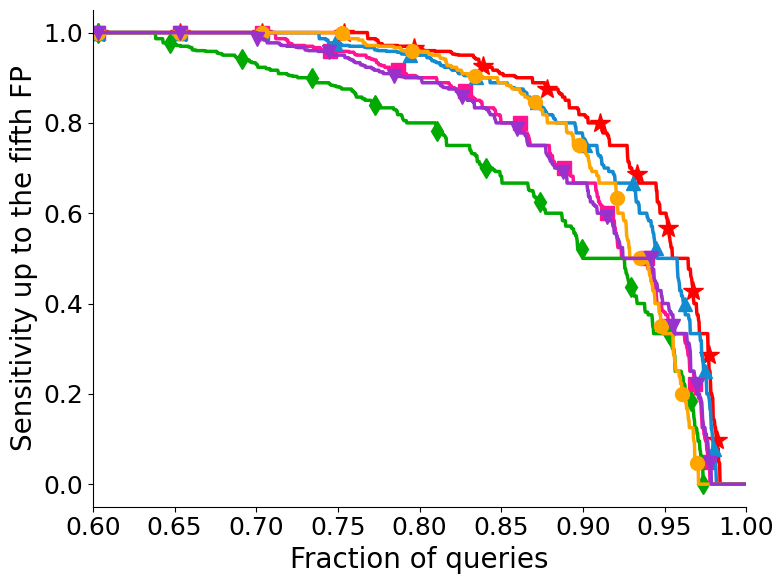

In [57]:
plt.plot(scale, np.sort(scope_lol_ns_len["FAM"].values)[::-1],
         label='LoLalign', color=colors["LoLalign"], linewidth=2.5,
         marker='*', markersize=15, markevery=0.1)

plt.plot(scale, np.sort(scope_lol_ns_len_pref["FAM"].values)[::-1],
         label='Foldseek-LoL', color=colors["Foldseek-LoL"], linewidth=2.5,
         marker='s', markersize=10, markevery=0.1)

plt.plot(scale, np.sort(scope_tm["FAM"].values)[::-1],
         label='TM-align', color=colors["TM-align"], linewidth=2.5,
         marker='^', markersize=10, markevery=0.1)

plt.plot(scale, np.sort(scope_fs["FAM"].values)[::-1],
         label='Foldseek', color=colors["Foldseek"], linewidth=2.5,
         marker='d', markersize=10, markevery=0.1)

plt.plot(scale, np.sort(scope_dali["FAM"].values)[::-1],
         label='Dali', color=colors["Dali"], linewidth=2.5,
         marker='o', markersize=10, markevery=0.1)

plt.plot(scale, np.sort(scope_tmpref["FAM"].values)[::-1],
         label='Foldseek-TM', color=colors["Foldseek-Tm"], linewidth=2.5,
         marker='v', markersize=10, markevery=0.1)

plt.xlim([0.2, 1])
plt.xlabel('Fraction of queries', fontsize=20)
plt.ylabel("Sensitivity up to the fifth FP", fontsize=20)
#plt.legend(frameon=True, fancybox=True, shadow=True,
 #          loc='lower left', fontsize=18)

# Improve axis limits and ticks
plt.xlim(0.6, 1)

plt.tick_params(labelsize=18)

# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('roc5_fam.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.savefig('roc5_fam.png', dpi=300, bbox_inches='tight', format='png')
plt.show()

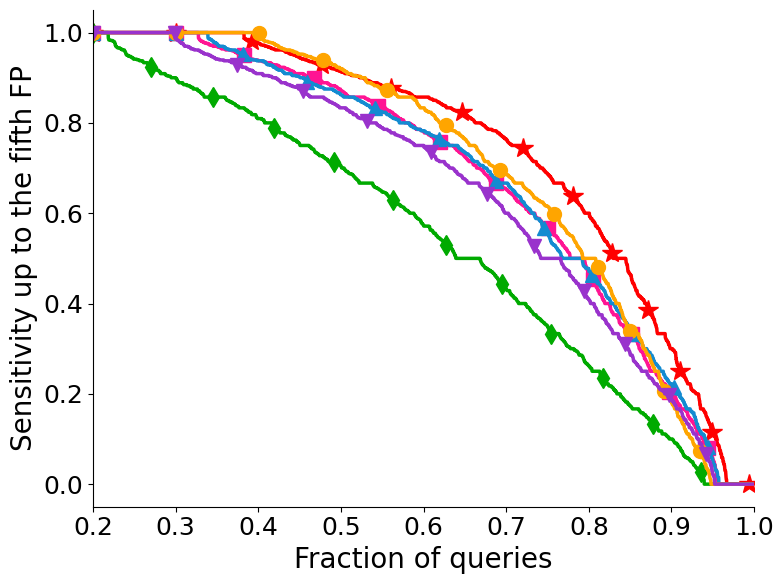

In [58]:
plt.plot(scale, np.sort(scope_lol_ns_len["SFAM"].values)[::-1],
         label='LoLalign', color=colors["LoLalign"], linewidth=2.5,
         marker='*', markersize=15, markevery=0.1)

plt.plot(scale, np.sort(scope_lol_ns_len_pref["SFAM"].values)[::-1],
         label='Foldseek-LoL', color=colors["Foldseek-LoL"], linewidth=2.5,
         marker='s', markersize=10, markevery=0.1)

plt.plot(scale, np.sort(scope_tm["SFAM"].values)[::-1],
         label='TM-align', color=colors["TM-align"], linewidth=2.5,
         marker='^', markersize=10, markevery=0.1)

plt.plot(scale, np.sort(scope_fs["SFAM"].values)[::-1],
         label='Foldseek', color=colors["Foldseek"], linewidth=2.5,
         marker='d', markersize=10, markevery=0.1)

plt.plot(scale, np.sort(scope_dali["SFAM"].values)[::-1],
         label='Dali', color=colors["Dali"], linewidth=2.5,
         marker='o', markersize=10, markevery=0.1)

plt.plot(scale, np.sort(scope_tmpref["SFAM"].values)[::-1],
         label='Foldseek-TM', color=colors["Foldseek-Tm"], linewidth=2.5,
         marker='v', markersize=10, markevery=0.1)

plt.xlim([0.2, 1])
plt.xlabel('Fraction of queries', fontsize=20)
plt.ylabel("Sensitivity up to the fifth FP", fontsize=20)
#plt.legend(frameon=True, fancybox=True, shadow=True,
#           loc='lower left', fontsize=18)

# Improve axis limits and ticks
plt.xlim(0.2, 1)

plt.tick_params(labelsize=18)

# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('roc5_sfam.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.savefig('roc5_sfam.png', dpi=300, bbox_inches='tight', format='png')
plt.show()

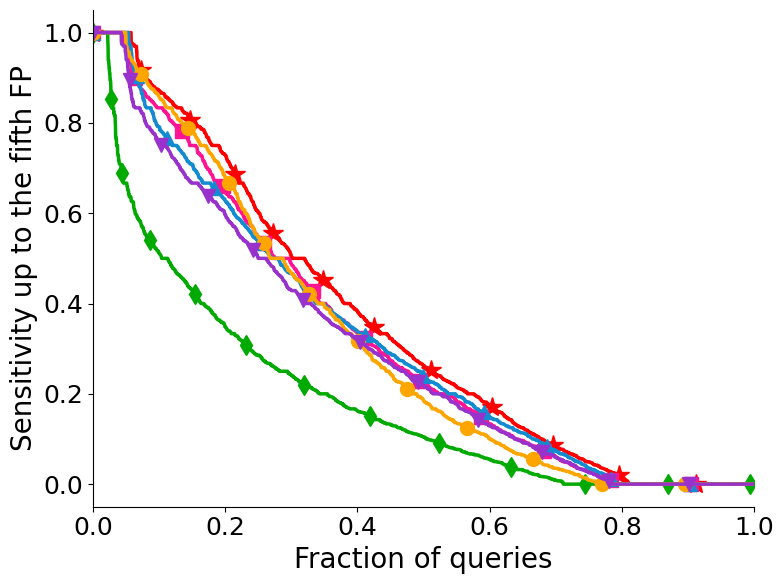

In [59]:
plt.plot(scale, np.sort(scope_lol_ns_len["FOLD"].values)[::-1],
         label='LoLalign', color=colors["LoLalign"], linewidth=2.5,
         marker='*', markersize=15, markevery=0.1)

plt.plot(scale, np.sort(scope_lol_ns_len_pref["FOLD"].values)[::-1],
         label='Foldseek-LoL', color=colors["Foldseek-LoL"], linewidth=2.5,
         marker='s', markersize=10, markevery=0.1)

plt.plot(scale, np.sort(scope_tm["FOLD"].values)[::-1],
         label='TM-align', color=colors["TM-align"], linewidth=2.5,
         marker='^', markersize=10, markevery=0.1)

plt.plot(scale, np.sort(scope_fs["FOLD"].values)[::-1],
         label='Foldseek', color=colors["Foldseek"], linewidth=2.5,
         marker='d', markersize=10, markevery=0.1)

plt.plot(scale, np.sort(scope_dali["FOLD"].values)[::-1],
         label='Dali', color=colors["Dali"], linewidth=2.5,
         marker='o', markersize=10, markevery=0.1)

plt.plot(scale, np.sort(scope_tmpref["FOLD"].values)[::-1],
         label='Foldseek-TM', color=colors["Foldseek-Tm"], linewidth=2.5,
         marker='v', markersize=10, markevery=0.1)

plt.xlim([0.2, 1])
plt.xlabel('Fraction of queries', fontsize=20)
plt.ylabel("Sensitivity up to the fifth FP", fontsize=20)
#plt.legend(frameon=True, fancybox=True, shadow=True,
#           loc='lower left', fontsize=18)

# Improve axis limits and ticks
plt.xlim(0, 1)

plt.tick_params(labelsize=18)

# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('roc5_fold.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.savefig('roc5_fold.png', dpi=300, bbox_inches='tight', format='png')
plt.show()

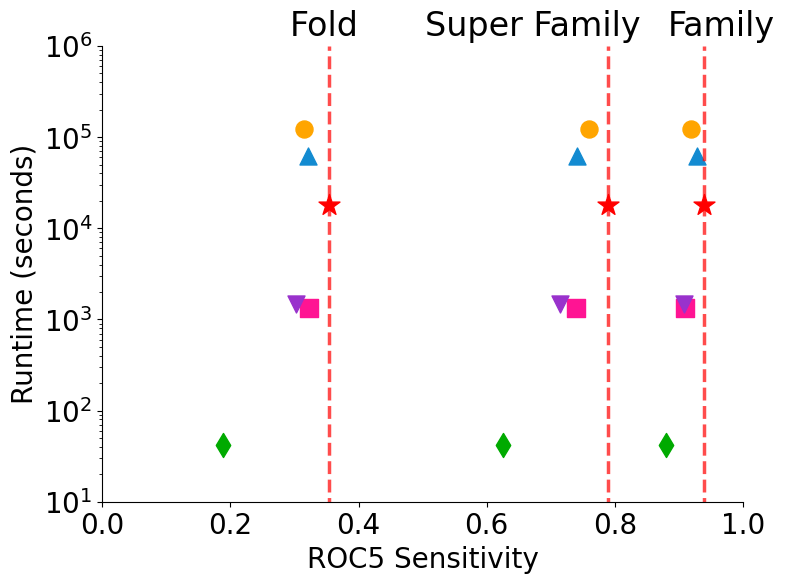

In [62]:
methods = ["LoL-align", "Foldseek-LoL", "Dali", "TM-align Fast", "Foldseek", "Foldseek-TM"]
method_keys = ["LoLalign", "Foldseek-LoL", "Dali", "TM-align", "Foldseek", "Foldseek-Tm"]
data_sources = [scope_lol_ns_len, scope_lol_ns_len_pref, scope_dali, scope_tm, scope_fs, scope_tmpref]
runtime_indices = [3, 4, 0, 1, 2, 5]
markers = ['*', 's', 'o', '^', 'd', 'v']

categories = ["FAM", "SFAM", "FOLD"]
category_labels = ["Family", "Superfamily", "Fold"]

for cat_idx, (cat, cat_label) in enumerate(zip(categories, category_labels)):
    sensitivities = []
    for data in data_sources:
        sens = data[cat].values.mean()
        sensitivities.append(sens)
    
    # Plot each method for this category
    for i, (method, key, sens, runtime_idx, marker) in enumerate(zip(methods, method_keys, sensitivities, runtime_indices, markers)):
        if marker == '*':
            plt.scatter(sens, runtime[runtime_idx], 
                  label=f"{method} ({cat_label})" if cat_idx == 0 else "", 
                  color=colors[key], marker=marker, s=250)
            plt.vlines(sens, 0, 10**6, color=colors[key], linewidth=2.5, alpha=0.7, linestyles='dashed')

        else:
            plt.scatter(sens, runtime[runtime_idx], 
                  label=f"{method} ({cat_label})" if cat_idx == 0 else "", 
                  color=colors[key], marker=marker, s=150)

plt.yscale('log')
plt.ylim([10, 10**6])
plt.xlim([0, 1])
plt.ylabel("Runtime (seconds)", fontsize=20)
plt.xlabel("ROC5 Sensitivity", fontsize=20)
plt.tick_params(labelsize=20)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

(ax.text(0.4, 1.08, 'Fold', transform=ax.transAxes, fontsize=24, va='top', ha='right'))
(ax.text(0.84, 1.08, 'Super Family', transform=ax.transAxes, fontsize=24, va='top', ha='right'))
(ax.text(1.05, 1.08, 'Family', transform=ax.transAxes, fontsize=24, va='top', ha='right'))

plt.tight_layout()
plt.savefig('roc5_speed.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.savefig('roc5_speed.png', dpi=300, bbox_inches='tight', format='png')
plt.show()